### Packages and Frameworks

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

import math

from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix, accuracy_score

from tensorflow import keras

2025-08-31 13:10:55.624097: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.
2025-08-31 13:10:55.679287: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 AVX512F AVX512_VNNI FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
2025-08-31 13:10:57.359953: I tensorflow/core/util/port.cc:153] oneDNN custom operations are on. You may see slightly different numerical results due to floating-point round-off errors from different computation orders. To turn them off, set the environment variable `TF_ENABLE_ONEDNN_OPTS=0`.


### Questão 2

O conjunto de dados Wine  Quality  Dataset contém medições físico-químicas de vinhos (como acidez, teor alcoólico e pH) e uma nota de qualidade atribuída por especialistas. Esse problema é amplamente utilizado para estudo de classificação supervisionada, pois envolve a 
relação entre variáveis químicas e uma avaliação subjetiva de qualidade. Aplique as técnicas de pré-processamento de dados vistas em salas de aula. Em seguida, divida os dados em conjuntos  de  treinamento  e  de  teste,  e  implemente  e  treine  uma  Rede  Perceptron  de 
Múltiplas Camadas (MLP) para classificar a qualidade de vinhos.

Apresente  também  as  curvas  de  erro  de  treinamento  e  validação,  e  calcule  a  matriz  de confusão. 
 
Algumas recomendações:  
* Verifique a existência de valores ausentes ou inconsistentes e trate-os adequadamente.
* Analise  a distribuição da variável-alvo e verifique se há desbalanceamento entre as classes.  
* Calcule correlações entre atributos e o rótulo de qualidade, removendo ou mantendo atributos com base nessa análise. 
* Aplique normalização ou padronização das variáveis numéricas, justificando a escolha. 
* Registre e compare estatísticas antes e depois do pré-processamento. 

#### Data Reading

In [2]:
df_red = pd.read_csv("../data/wine_quality/winequality-red.csv", delimiter=";")
df_white = pd.read_csv("../data/wine_quality/winequality-white.csv", delimiter=";")

df = pd.concat([df_red, df_white])

#### Auxiliary Functions

In [3]:
def sturges_bins(x):
    x = np.asarray(x)
    x = x[~np.isnan(x)]
    n = len(x)
    if n <= 1:
        return 1, np.inf

    k = math.ceil(math.log2(n)) + 1
    data_range = x.max() - x.min()
    h = data_range / k if data_range > 0 else np.inf
    h = math.ceil(h)
    
    return k, h

#### Red Wine

In [4]:
display(df_red)
display(df_red.info())
display(df_red.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
1,7.8,0.880,0.00,2.6,0.098,25.0,67.0,0.99680,3.20,0.68,9.8,5
2,7.8,0.760,0.04,2.3,0.092,15.0,54.0,0.99700,3.26,0.65,9.8,5
3,11.2,0.280,0.56,1.9,0.075,17.0,60.0,0.99800,3.16,0.58,9.8,6
4,7.4,0.700,0.00,1.9,0.076,11.0,34.0,0.99780,3.51,0.56,9.4,5
...,...,...,...,...,...,...,...,...,...,...,...,...
1594,6.2,0.600,0.08,2.0,0.090,32.0,44.0,0.99490,3.45,0.58,10.5,5
1595,5.9,0.550,0.10,2.2,0.062,39.0,51.0,0.99512,3.52,0.76,11.2,6
1596,6.3,0.510,0.13,2.3,0.076,29.0,40.0,0.99574,3.42,0.75,11.0,6
1597,5.9,0.645,0.12,2.0,0.075,32.0,44.0,0.99547,3.57,0.71,10.2,5


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1599 entries, 0 to 1598
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         1599 non-null   float64
 1   volatile acidity      1599 non-null   float64
 2   citric acid           1599 non-null   float64
 3   residual sugar        1599 non-null   float64
 4   chlorides             1599 non-null   float64
 5   free sulfur dioxide   1599 non-null   float64
 6   total sulfur dioxide  1599 non-null   float64
 7   density               1599 non-null   float64
 8   pH                    1599 non-null   float64
 9   sulphates             1599 non-null   float64
 10  alcohol               1599 non-null   float64
 11  quality               1599 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 150.0 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000,1599.000000
mean,8.319637,0.527821,0.270976,2.538806,0.087467,15.874922,46.467792,0.996747,3.311113,0.658149,10.422983,5.636023
std,1.741096,0.179060,0.194801,1.409928,0.047065,10.460157,32.895324,0.001887,0.154386,0.169507,1.065668,0.807569
min,4.600000,0.120000,0.000000,0.900000,0.012000,1.000000,6.000000,0.990070,2.740000,0.330000,8.400000,3.000000
25%,7.100000,0.390000,0.090000,1.900000,0.070000,7.000000,22.000000,0.995600,3.210000,0.550000,9.500000,5.000000
50%,7.900000,0.520000,0.260000,2.200000,0.079000,14.000000,38.000000,0.996750,3.310000,0.620000,10.200000,6.000000
75%,9.200000,0.640000,0.420000,2.600000,0.090000,21.000000,62.000000,0.997835,3.400000,0.730000,11.100000,6.000000
max,15.900000,1.580000,1.000000,15.500000,0.611000,72.000000,289.000000,1.003690,4.010000,2.000000,14.900000,8.000000


In [5]:
red_wines = df_red.quality.unique().tolist()
print(f"Categorias de vinhos tintos: {sorted(red_wines)}.")

Categorias de vinhos tintos: [3, 4, 5, 6, 7, 8].


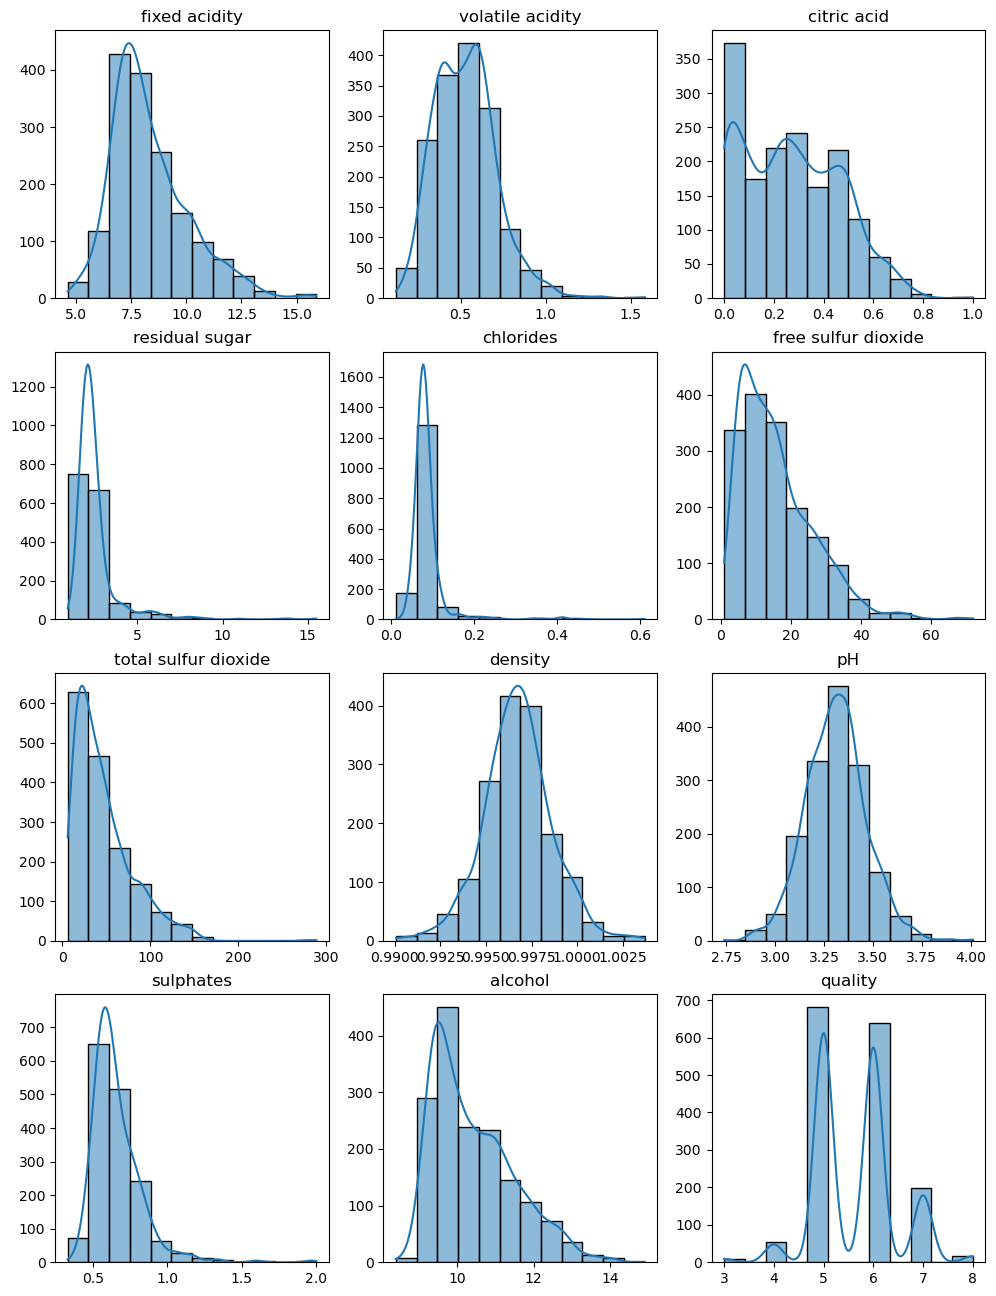

In [6]:
# Plot of Histograms

fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(12, 16))
axes = axes.flatten()

for idx, col in enumerate(df_red.columns):
    data = df_red[col].values
    k, _ = sturges_bins(data)

    sns.histplot(data=df_red, x=col, bins=k, kde=True, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

#### White Wine

In [7]:
display(df_white)
display(df_white.info())
display(df_white.describe())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.0,0.27,0.36,20.7,0.045,45.0,170.0,1.00100,3.00,0.45,8.8,6
1,6.3,0.30,0.34,1.6,0.049,14.0,132.0,0.99400,3.30,0.49,9.5,6
2,8.1,0.28,0.40,6.9,0.050,30.0,97.0,0.99510,3.26,0.44,10.1,6
3,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
4,7.2,0.23,0.32,8.5,0.058,47.0,186.0,0.99560,3.19,0.40,9.9,6
...,...,...,...,...,...,...,...,...,...,...,...,...
4893,6.2,0.21,0.29,1.6,0.039,24.0,92.0,0.99114,3.27,0.50,11.2,6
4894,6.6,0.32,0.36,8.0,0.047,57.0,168.0,0.99490,3.15,0.46,9.6,5
4895,6.5,0.24,0.19,1.2,0.041,30.0,111.0,0.99254,2.99,0.46,9.4,6
4896,5.5,0.29,0.30,1.1,0.022,20.0,110.0,0.98869,3.34,0.38,12.8,7


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4898 entries, 0 to 4897
Data columns (total 12 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fixed acidity         4898 non-null   float64
 1   volatile acidity      4898 non-null   float64
 2   citric acid           4898 non-null   float64
 3   residual sugar        4898 non-null   float64
 4   chlorides             4898 non-null   float64
 5   free sulfur dioxide   4898 non-null   float64
 6   total sulfur dioxide  4898 non-null   float64
 7   density               4898 non-null   float64
 8   pH                    4898 non-null   float64
 9   sulphates             4898 non-null   float64
 10  alcohol               4898 non-null   float64
 11  quality               4898 non-null   int64  
dtypes: float64(11), int64(1)
memory usage: 459.3 KB


None

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
count,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000,4898.000000
mean,6.854788,0.278241,0.334192,6.391415,0.045772,35.308085,138.360657,0.994027,3.188267,0.489847,10.514267,5.877909
std,0.843868,0.100795,0.121020,5.072058,0.021848,17.007137,42.498065,0.002991,0.151001,0.114126,1.230621,0.885639
min,3.800000,0.080000,0.000000,0.600000,0.009000,2.000000,9.000000,0.987110,2.720000,0.220000,8.000000,3.000000
25%,6.300000,0.210000,0.270000,1.700000,0.036000,23.000000,108.000000,0.991723,3.090000,0.410000,9.500000,5.000000
50%,6.800000,0.260000,0.320000,5.200000,0.043000,34.000000,134.000000,0.993740,3.180000,0.470000,10.400000,6.000000
75%,7.300000,0.320000,0.390000,9.900000,0.050000,46.000000,167.000000,0.996100,3.280000,0.550000,11.400000,6.000000
max,14.200000,1.100000,1.660000,65.800000,0.346000,289.000000,440.000000,1.038980,3.820000,1.080000,14.200000,9.000000


In [8]:
white_wines = df_white.quality.unique().tolist()
print(f"Categorias de vinhos brancos: {sorted(white_wines)}.")

Categorias de vinhos brancos: [3, 4, 5, 6, 7, 8, 9].


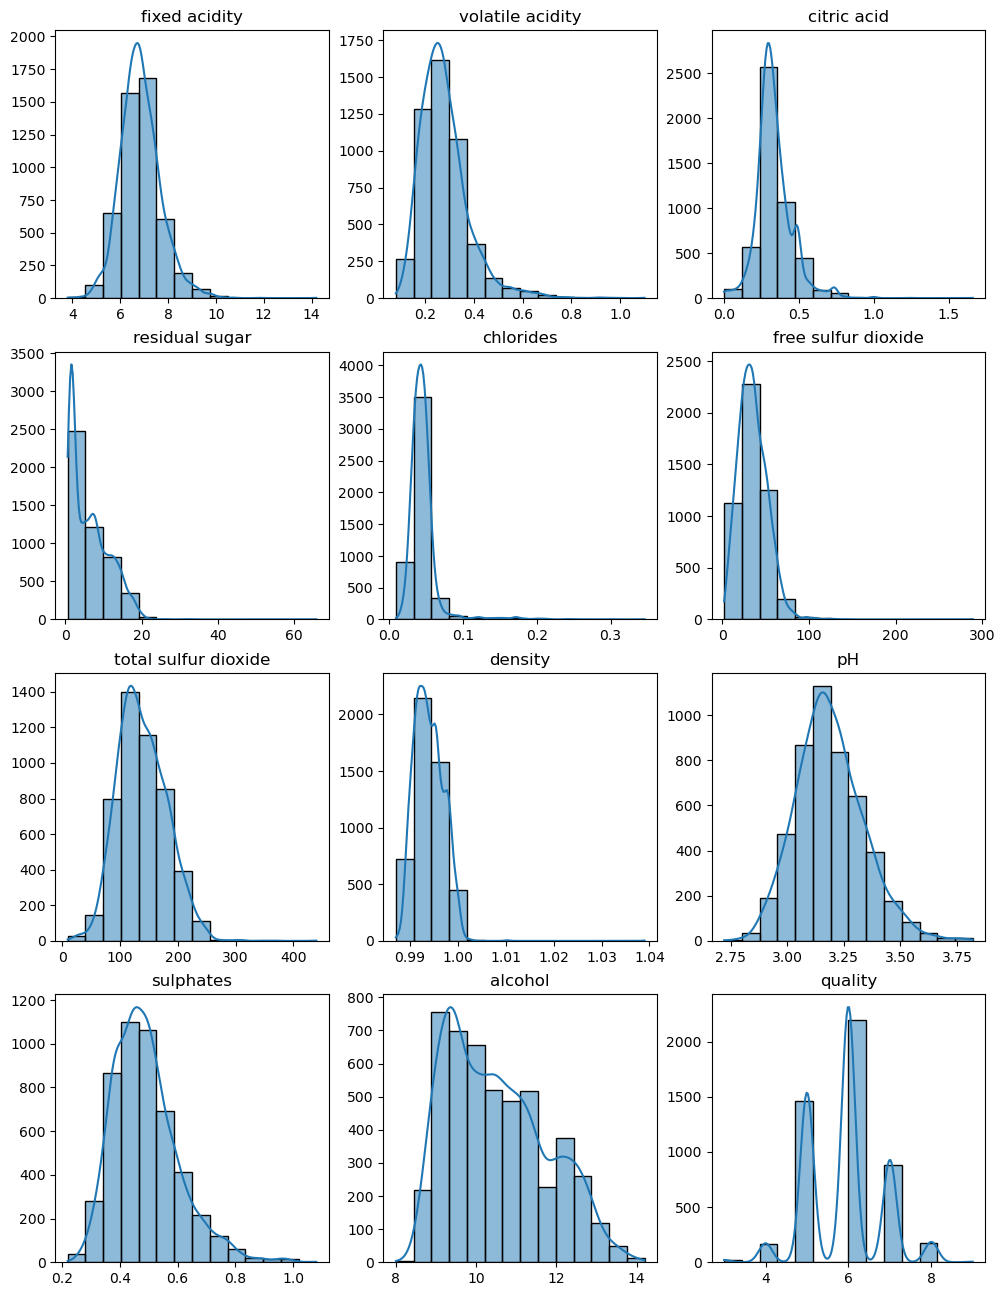

In [9]:
# Plot of Histograms

fig, axes = plt.subplots(ncols=3, nrows=4, figsize=(12, 16))
axes = axes.flatten()

for idx, col in enumerate(df_white.columns):
    data = df_white[col].values
    k, _ = sturges_bins(data)

    sns.histplot(data=df_white, x=col, bins=k, kde=True, ax=axes[idx])
    axes[idx].set_title(f"{col}")
    axes[idx].set_xlabel("")
    axes[idx].set_ylabel("")

#### Model

In [10]:
# Data

num_classes = 11

X = df.loc[:, df.columns[df.columns != "quality"]].values

y = df.loc[:, "quality"].values
y = keras.utils.to_categorical(y, num_classes=num_classes)

scaler = MinMaxScaler()
X_normalized = scaler.fit_transform(X)

X_train_full, X_test, y_train_full, y_test = train_test_split(
    X_normalized, y, test_size=0.2, random_state=42
)
X_train, X_valid, y_train, y_valid = train_test_split(
    X_train_full, y_train_full, test_size=0.2, random_state=42
)

In [11]:
# Model

input_ = keras.layers.Input(shape=X_train.shape[1:])
hidden1 = keras.layers.Dense(250, activation="relu")(input_)
hidden2 = keras.layers.Dense(100, activation="relu")(hidden1)
hidden3 = keras.layers.Dense(50, activation="relu")(hidden2)
output = keras.layers.Dense(num_classes, activation="softmax")(hidden3)

model = keras.Model(inputs=[input_], outputs=[output])
model.compile(loss="categorical_crossentropy", optimizer="adam")
model.summary()

2025-08-31 13:11:00.900787: E external/local_xla/xla/stream_executor/cuda/cuda_platform.cc:51] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: CUDA_ERROR_NO_DEVICE: no CUDA-capable device is detected


Model: "functional"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 11)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 250)            │         3,000 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 100)            │        25,100 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 50)             │         5,050 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 11)             │           561 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 33,711 (131.68 KB)

 Trainable params: 33,711 (131.68 KB)

 Non-trainable params: 0 (0.00 B)

In [12]:
# Train

history = model.fit(X_train, y_train, epochs=100, validation_data=(X_valid, y_valid))

# Prediction

y_pred = model.predict(X_test)

Epoch 1/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - loss: 1.3542 - val_loss: 1.1959
Epoch 2/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1242 - val_loss: 1.1501
Epoch 3/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.1032 - val_loss: 1.1416
Epoch 4/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0912 - val_loss: 1.1264
Epoch 5/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0808 - val_loss: 1.1140
Epoch 6/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0765 - val_loss: 1.1129
Epoch 7/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 1.0674 - val_loss: 1.1061
Epoch 8/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0632 - val_loss: 1.1028
Epoch 9/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0522 - val_loss: 1.1199
Epoch 10/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0515 - val_loss: 1.0914
Epoch 11/100
130/130 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 1.0439 - val_loss: 1.0990
Epoch 12/100
130/130 ━━━━━━━━━━━━━━━━━━━━

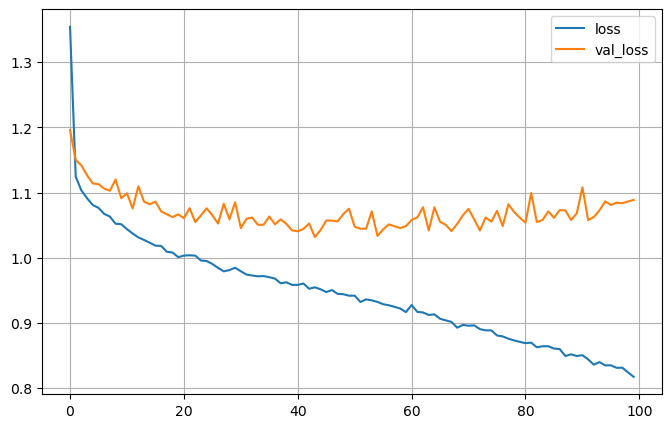

In [13]:
# Training Metrics

pd.DataFrame(history.history).plot(figsize=(8, 5))
plt.grid(True)
plt.show()

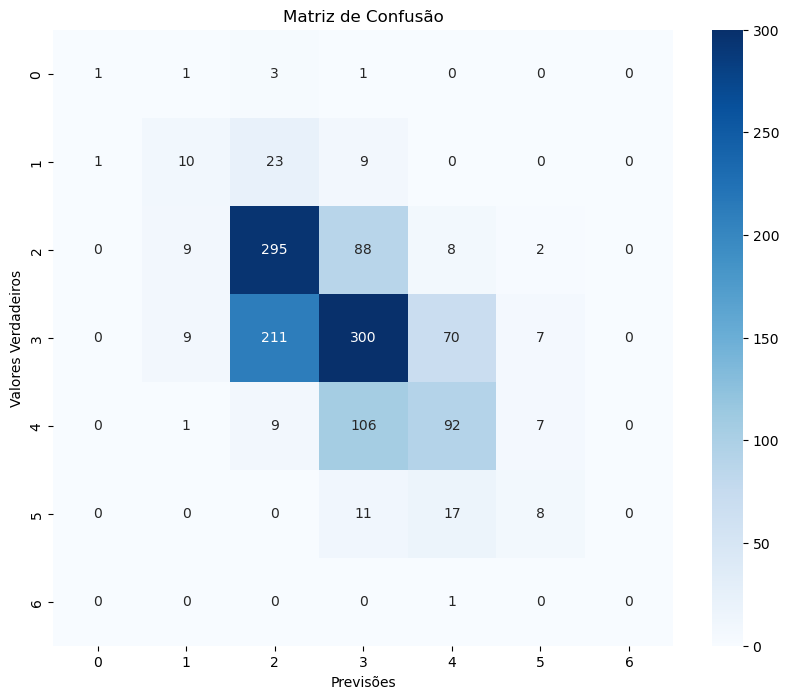

Acurácia do modelo: 0.5431


In [14]:
# Metrics

y_pred = np.argmax(y_pred, axis=1)
y_test = np.argmax(y_test, axis=1)

# Confusion Matrix

cm = confusion_matrix(y_true=y_test, y_pred=y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Previsões')
plt.ylabel('Valores Verdadeiros')
plt.title('Matriz de Confusão')
plt.show()

# Accuracy

accuracy = accuracy_score(y_true=y_test, y_pred=y_pred)
print(f"Acurácia do modelo: {accuracy:.4f}")